In [1]:
# Library Import
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
# Loading Data into the Model
df = pd.read_csv("../data/data.csv")
df.head()

,record_id,machine_id,machine_type,temperature_c,vibration_mms,running_hours,pressure_bar,sound_db,status
0,1,M001,Motor,49.03,1.209,515.6,3.899,60.35,Normal
1,2,M015,Fan,47.25,4.078,3820.1,3.030,63.29,Normal
2,3,M009,Pump,68.27,1.954,4906.8,3.200,64.22,Normal
3,4,M008,Pump,55.97,1.777,4113.7,3.015,60.40,Normal
4,5,M015,Conveyor,55.25,3.994,3467.9,2.913,64.92,Normal


In [4]:
print(f"Shape: {df.shape}")

Shape: (12000, 9)


In [10]:
print("\nDetailed Info:\n")
df.info()


Detailed Info:

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   record_id      12000 non-null  int64  
 1   machine_id     12000 non-null  str    
 2   machine_type   12000 non-null  str    
 3   temperature_c  12000 non-null  float64
 4   vibration_mms  12000 non-null  float64
 5   running_hours  12000 non-null  float64
 6   pressure_bar   12000 non-null  float64
 7   sound_db       12000 non-null  float64
 8   status         12000 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.0 MB


In [6]:
print(f"\nClass distribution:")
print(df["status"].value_counts())


Class distribution:
status
Normal     8412
Warning    2385
Fault      1203
Name: count, dtype: int64


In [21]:
print(f"\nMachine types: {df['machine_type'].unique()}")
print(f"\nMachine ID: {df['machine_id'].unique()}")



Machine types: <ArrowStringArray>
['Motor', 'Fan', 'Pump', 'Conveyor', 'Compressor']
Length: 5, dtype: str

Machine ID: <ArrowStringArray>
['M001', 'M015', 'M009', 'M008', 'M007', 'M017', 'M018', 'M019', 'M002',
 'M014', 'M013', 'M004', 'M003', 'M010', 'M011', 'M006', 'M012', 'M005',
 'M020', 'M016']
Length: 20, dtype: str


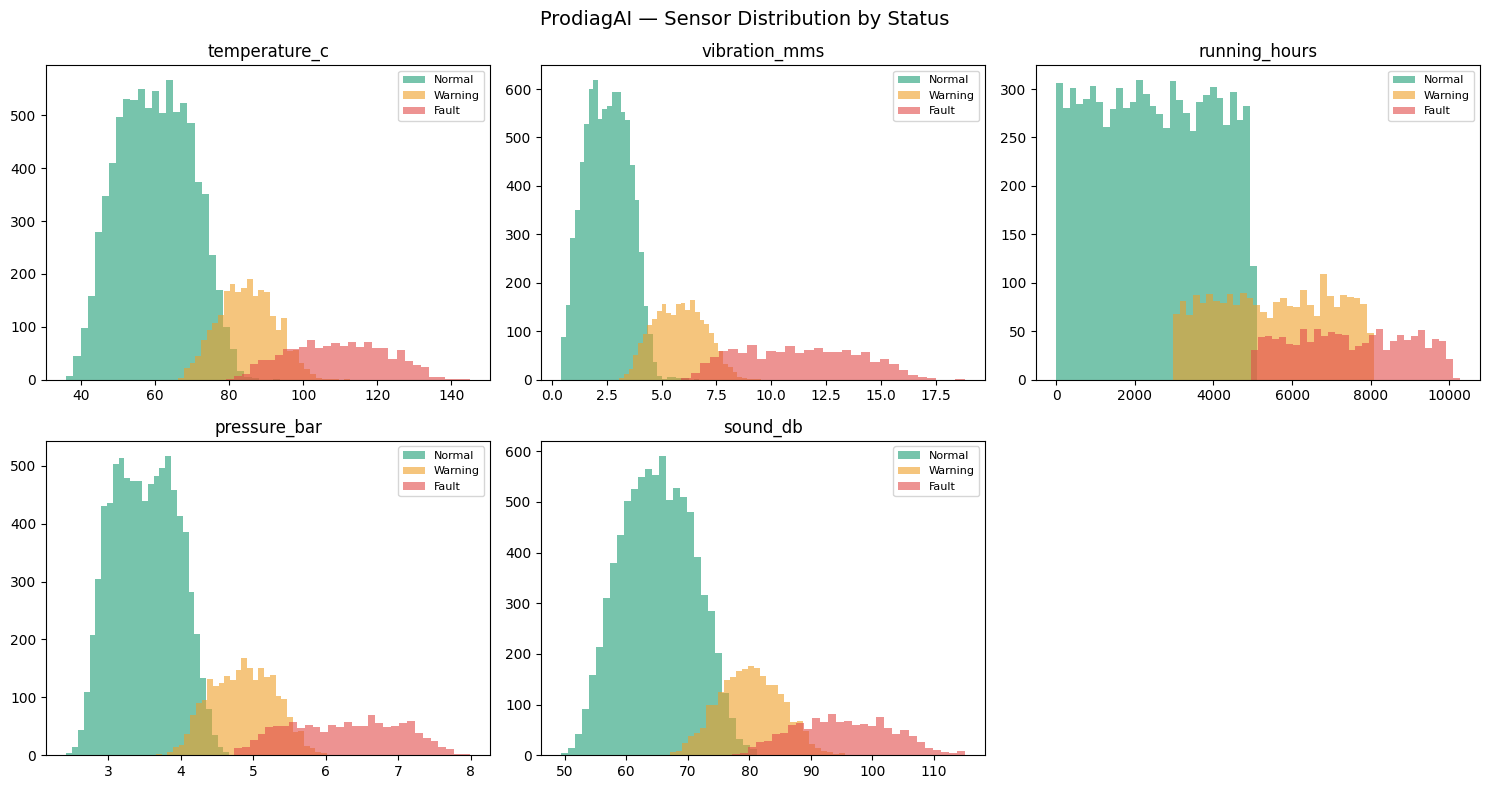

EDA plot saved


In [9]:
# EDA plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("ProdiagAI — Sensor Distribution by Status", fontsize=14)

sensors = ["temperature_c", "vibration_mms", "running_hours",
           "pressure_bar", "sound_db"]
colors  = {"Normal": "#1D9E75", "Warning": "#EF9F27", "Fault": "#E24B4A"}

for i, sensor in enumerate(sensors):
    ax = axes[i//3][i%3]
    for status, color in colors.items():
        subset = df[df["status"] == status][sensor]
        ax.hist(subset, bins=30, alpha=0.6, label=status, color=color)
    ax.set_title(sensor)
    ax.legend(fontsize=8)

axes[1][2].axis("off")
plt.tight_layout()
plt.savefig("../reports/eda_sensor_distributions.png", dpi=150)
plt.show()
print("EDA plot saved")

In [11]:
# Encode & prepare features
le_type   = LabelEncoder()
le_id     = LabelEncoder()
le_status = LabelEncoder()

df["machine_type_enc"] = le_type.fit_transform(df["machine_type"])
df["machine_id_enc"]   = le_id.fit_transform(df["machine_id"])
df["status_enc"]       = le_status.fit_transform(df["status"])

FEATURES = [
    "temperature_c", "vibration_mms", "running_hours",
    "pressure_bar", "sound_db",
    "machine_type_enc", "machine_id_enc"
]

X = df[FEATURES]
y = df["status_enc"]

print(f"Features: {FEATURES}")
print(f"Classes:  {list(le_status.classes_)}")
print(f"X shape:  {X.shape}")

Features: ['temperature_c', 'vibration_mms', 'running_hours', 'pressure_bar', 'sound_db', 'machine_type_enc', 'machine_id_enc']
Classes:  ['Fault', 'Normal', 'Warning']
X shape:  (12000, 7)


In [12]:
# Train/test split + scale + SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

print(f"Train: {X_train.shape[0]} → After SMOTE: {X_train_sm.shape[0]}")
print(f"Test:  {X_test.shape[0]} rows (no SMOTE)")
print(f"\nAfter SMOTE class balance:")
counts = pd.Series(y_train_sm).value_counts().sort_index()
for i, c in enumerate(le_status.classes_):
    print(f"  {c}: {counts[i]}")

Train: 8400 → After SMOTE: 17664
Test:  3600 rows (no SMOTE)

After SMOTE class balance:
  Fault: 5888
  Normal: 5888


In [13]:
# Train XGBoost (Initial)
xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, random_state=42,
    eval_metric="mlogloss", verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)
xgb_preds = xgb.predict(X_test_sc)

print("=" * 50)
print("XGBoost — Classification Report")
print("=" * 50)
print(classification_report(
    y_test, xgb_preds,
    target_names=le_status.classes_
))

# CV score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb, X_train_sm, y_train_sm,
    cv=cv, scoring="f1_weighted"
)
print(f"CV F1 (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

XGBoost — Classification Report
              precision    recall  f1-score   support

       Fault       1.00      0.99      1.00       361
      Normal       1.00      1.00      1.00      2524
     Warning       1.00      1.00      1.00       715

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600

CV F1 (5-fold): 0.999 ± 0.000


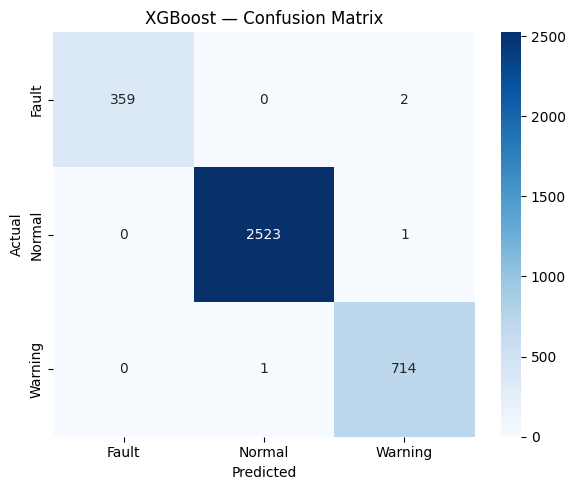

In [14]:
# Confusion matrix
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le_status.classes_,
    yticklabels=le_status.classes_
)
plt.title("XGBoost — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix_xgb.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

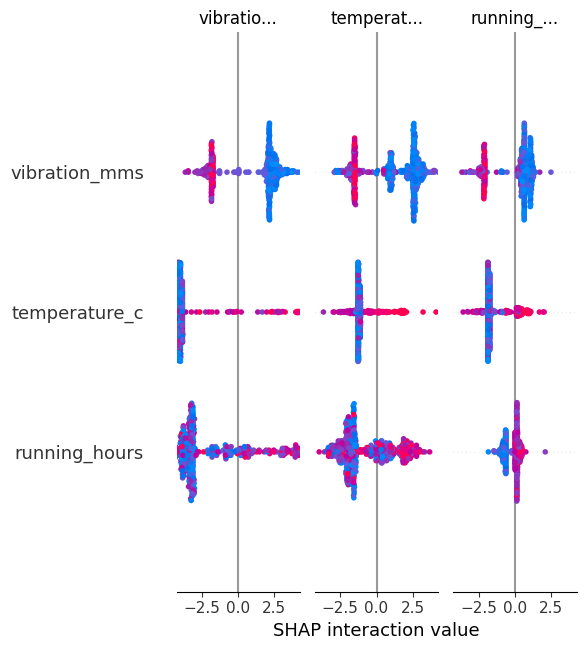

SHAP plot saved


In [15]:
# SHAP feature importance
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sc[:500])

plt.figure()
shap.summary_plot(
    shap_values, X_test_sc[:500],
    feature_names=FEATURES,
    class_names=list(le_status.classes_),
    show=False
)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved")

In [16]:
# Save all artefacts
with open("../models/xgb_model.pkl", "wb") as f: pickle.dump(xgb, f)
with open("../models/scaler.pkl",    "wb") as f: pickle.dump(scaler, f)
with open("../models/label_enc.pkl", "wb") as f: pickle.dump(le_status, f)
with open("../models/type_enc.pkl",  "wb") as f: pickle.dump(le_type, f)
with open("../models/id_enc.pkl",    "wb") as f: pickle.dump(le_id, f)

print("All artefacts saved to models/")
print("\nFiles saved:")
for f in os.listdir("../models"):
    print(f"  {f}")

All artefacts saved to models/

Files saved:
  id_enc.pkl
  label_enc.pkl
  scaler.pkl
  type_enc.pkl
  xgb_model.pkl


In [19]:
# Quick prediction test (verify pkl works)
with open("../models/xgb_model.pkl", "rb") as f: model_loaded = pickle.load(f)
with open("../models/scaler.pkl",    "rb") as f: scaler_loaded = pickle.load(f)
with open("../models/label_enc.pkl", "rb") as f: le_loaded = pickle.load(f)

# Test sample 
sample = pd.DataFrame([{
    "temperature_c": 110, "vibration_mms": 12.0, "running_hours": 7500,
    "pressure_bar": 6.0,  "sound_db": 92,
    "machine_type_enc": 0, "machine_id_enc": 0
}])

sample_sc = scaler_loaded.transform(sample)
pred_enc  = model_loaded.predict(sample_sc)
pred_prob = model_loaded.predict_proba(sample_sc)
pred_label = le_loaded.inverse_transform(pred_enc)[0]

print(f"Test prediction:  {pred_label}")
print(f"Confidence:       {pred_prob.max()*100:.1f}%")

Test prediction:  Fault
Confidence:       100.0%
